In [1]:
import pandas as pd
import numpy as np
import tidyfinance as tf

In [2]:
prices = tf.download_data(
  domain="stock_prices", 
  symbols="AAPL",
  start_date="2000-01-01", 
  end_date="2023-12-31"
)
prices.head().round(3)

,date,symbol,volume,open,low,high,close,adjusted_close
0,2000-01-03,AAPL,535796800,0.936,0.908,1.004,0.999,0.840
1,2000-01-04,AAPL,512377600,0.967,0.903,0.988,0.915,0.769
2,2000-01-05,AAPL,778321600,0.926,0.920,0.987,0.929,0.781
3,2000-01-06,AAPL,767972800,0.948,0.848,0.955,0.848,0.713
4,2000-01-07,AAPL,460734400,0.862,0.853,0.902,0.888,0.747


In [3]:
from plotnine import *

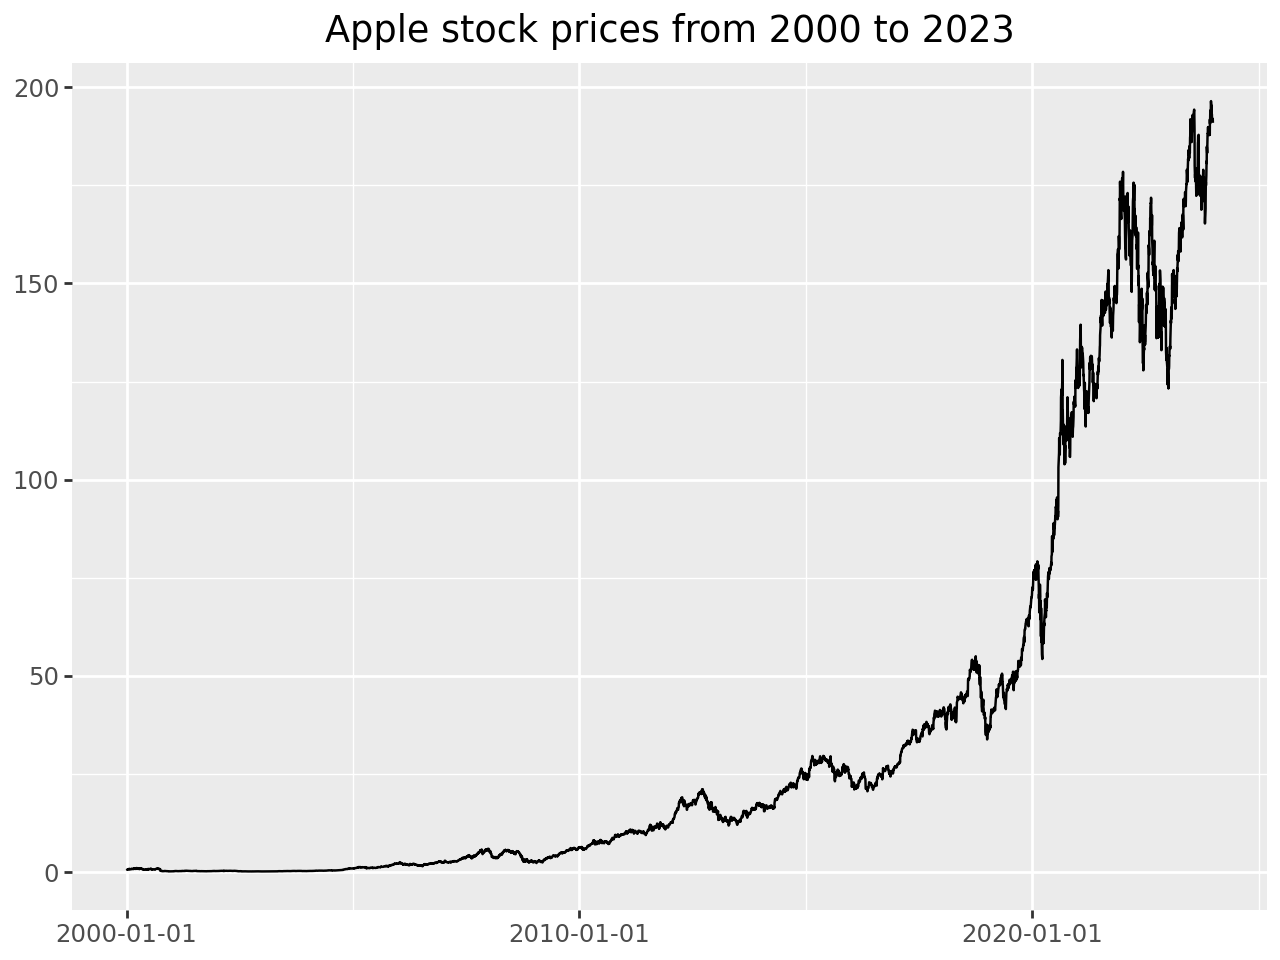

In [4]:
apple_prices_figure = (
  ggplot(prices, aes(y="adjusted_close", x="date"))
  + geom_line()
  + labs(x="", y="", title="Apple stock prices from 2000 to 2023")
)
apple_prices_figure.show()

In [5]:
returns = (prices
  .sort_values("date")
  .assign(ret=lambda x: x["adjusted_close"].pct_change())
  .get(["symbol", "date", "ret"])
)
returns

,symbol,date,ret
0,AAPL,2000-01-03,NaN
1,AAPL,2000-01-04,-0.084310
2,AAPL,2000-01-05,0.014633
3,AAPL,2000-01-06,-0.086538
4,AAPL,2000-01-07,0.047369
...,...,...,...
6032,AAPL,2023-12-22,-0.005548
6033,AAPL,2023-12-26,-0.002841
6034,AAPL,2023-12-27,0.000518
6035,AAPL,2023-12-28,0.002226


In [6]:
returns = returns.dropna() 

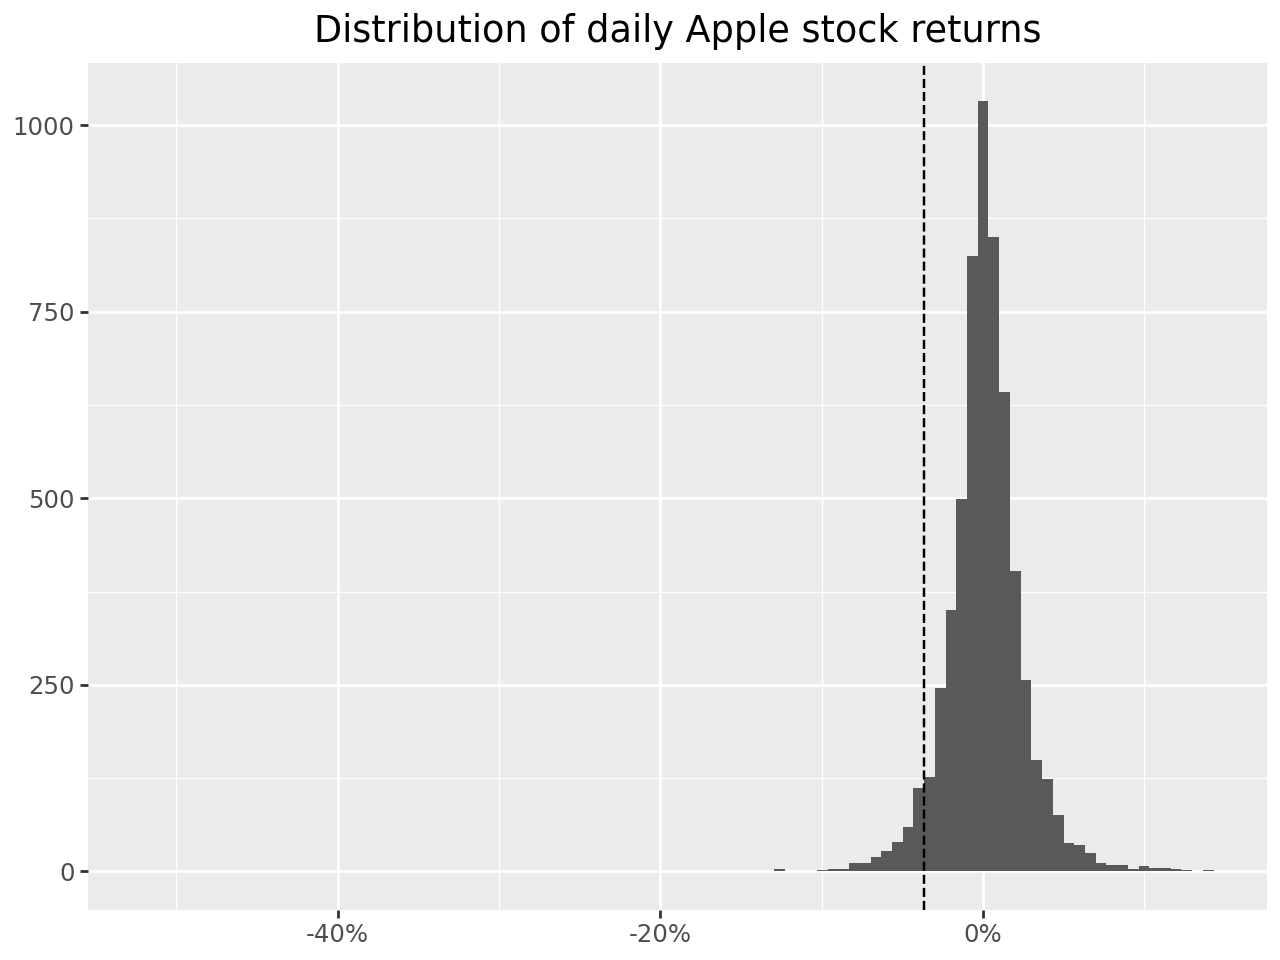

In [7]:
from mizani.formatters import percent_format

quantile_05 = returns["ret"].quantile(0.05)

apple_returns_figure = (
  ggplot(returns, aes(x="ret"))
  + geom_histogram(bins=100)
  + geom_vline(aes(xintercept=quantile_05), linetype="dashed")
  + labs(x="", y="", title="Distribution of daily Apple stock returns")
  + scale_x_continuous(labels=percent_format())
)
apple_returns_figure.show()

In [8]:
pd.DataFrame(returns["ret"].describe()).round(3).T

,count,mean,std,min,25%,50%,75%,max
ret,6036.0,0.001,0.025,-0.519,-0.01,0.001,0.013,0.139


In [9]:
(returns["ret"]
  .groupby(returns["date"].dt.year)
  .describe()
  .round(3)
)

,count,mean,std,min,25%,50%,75%,max
date,,,,,,,,
2000,251.0,-0.003,0.055,-0.519,-0.034,-0.002,0.027,0.137
2001,248.0,0.002,0.039,-0.172,-0.023,-0.001,0.027,0.129
2002,252.0,-0.001,0.031,-0.150,-0.019,-0.003,0.018,0.085
2003,252.0,0.002,0.023,-0.081,-0.012,0.002,0.015,0.113
2004,252.0,0.005,0.025,-0.056,-0.009,0.003,0.016,0.132
2005,252.0,0.003,0.024,-0.092,-0.010,0.003,0.017,0.091
2006,251.0,0.001,0.024,-0.063,-0.014,-0.002,0.014,0.118
2007,251.0,0.004,0.024,-0.070,-0.009,0.003,0.018,0.105
2008,253.0,-0.003,0.037,-0.179,-0.024,-0.001,0.019,0.139


In [10]:
symbols = tf.download_data(
  domain="constituents", 
  index="Dow Jones Industrial Average"
)

In [11]:
prices_daily = tf.download_data(
  domain="stock_prices", 
  symbols=symbols["symbol"].tolist(),
  start_date="2000-01-01", 
  end_date="2023-12-31"
)

Failed to retrieve data for GS (Status code: 429)
Failed to retrieve data for MSFT (Status code: 429)
Failed to retrieve data for CAT (Status code: 429)
Failed to retrieve data for HD (Status code: 429)
Failed to retrieve data for SHW (Status code: 429)
Failed to retrieve data for V (Status code: 429)
Failed to retrieve data for AXP (Status code: 429)
Failed to retrieve data for JPM (Status code: 429)
Failed to retrieve data for AMGN (Status code: 429)
Failed to retrieve data for TRV (Status code: 429)
Failed to retrieve data for IBM (Status code: 429)
Failed to retrieve data for CRM (Status code: 429)
Failed to retrieve data for AMZN (Status code: 429)
Failed to retrieve data for HON (Status code: 429)
Failed to retrieve data for NVDA (Status code: 429)
Failed to retrieve data for PG (Status code: 429)
Failed to retrieve data for MMM (Status code: 429)
Failed to retrieve data for WMT (Status code: 429)
Failed to retrieve data for MRK (Status code: 429)
Failed to retrieve data for KO (

/workspaces/cflabs/.venv/lib/python3.10/site-packages/mizani/breaks.py:448: FutureWarning: Passing the width as the parameter has been deprecated and will not work in a future version. Use breaks_date(width="4 years")


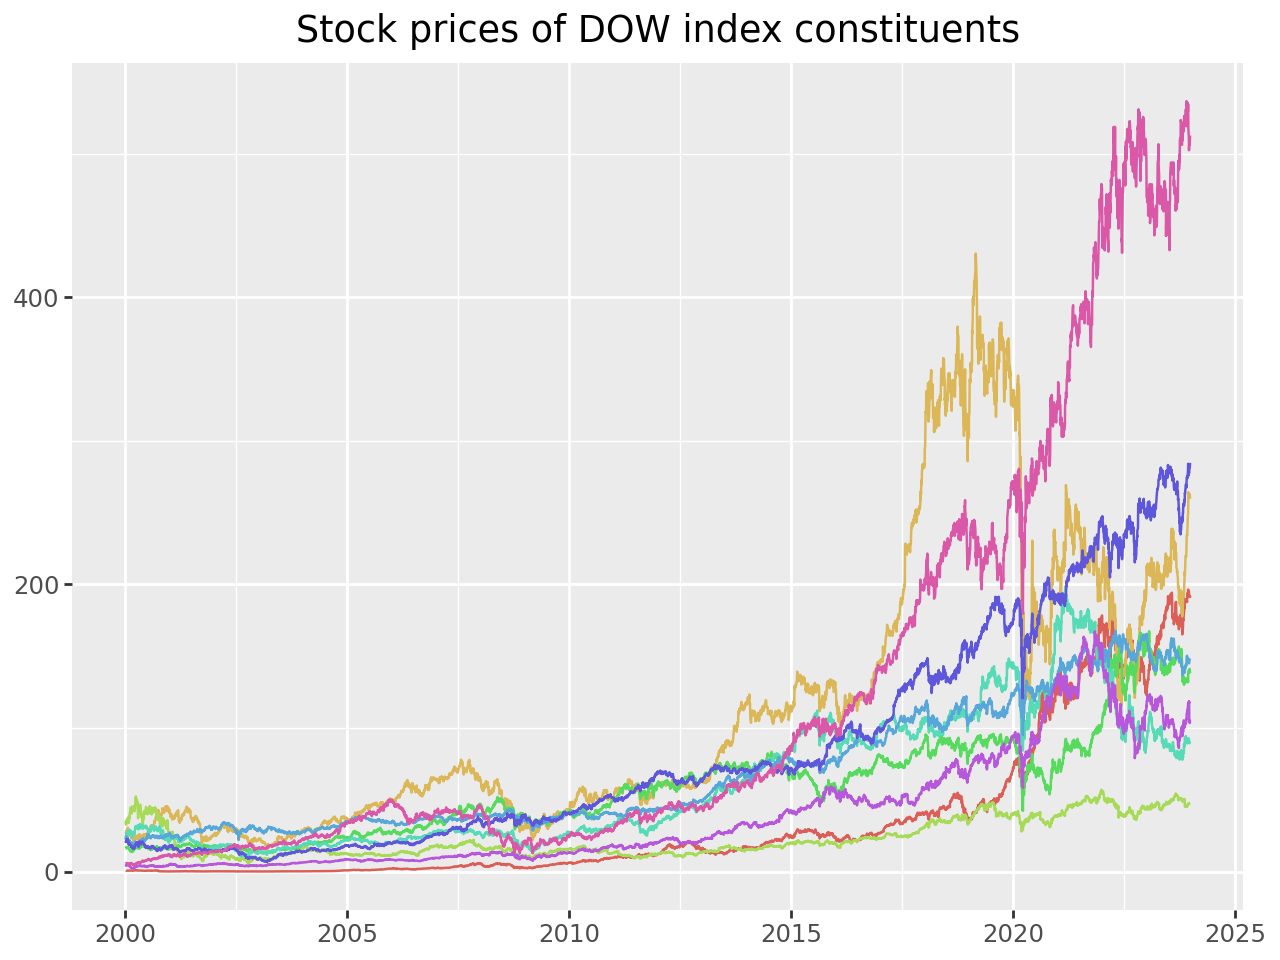

In [12]:
from mizani.breaks import date_breaks
from mizani.formatters import date_format

prices_figure = (
  ggplot(prices_daily, aes(y="adjusted_close", x="date", color="symbol"))
  + geom_line()
  + scale_x_datetime(date_breaks="5 years", date_labels="%Y")
  + labs(x="", y="", color="", title="Stock prices of DOW index constituents")
  + theme(legend_position="none")
)
prices_figure.show()

In [ ]:
returns_daily = (prices_daily
  .assign(ret=lambda x: x.groupby("symbol")["adjusted_close"].pct_change())
  .get(["symbol", "date", "ret"])
  .dropna(subset="ret")
)

(returns_daily
  .groupby("symbol")["ret"]
  .describe()
  .round(3)
)